# Customer Churn Prediction in a Subscription Service
## Supervised Learning & Explainable AI - Focus F

**Course:** Fundamentals of Python & Applications in Data Science
**Topic:** F1 - Predicting Customer Churn
**Author:** Joel Suhner

---

**Objective:** Develop classification models to predict whether a subscription customer will churn,
engineer meaningful features from raw behavioural signals, and use SHAP values to explain
which factors drive individual and global predictions - including a business-impact analysis
that quantifies revenue at risk and identifies optimal intervention thresholds.

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, average_precision_score,
    precision_recall_curve, f1_score, brier_score_loss,
)
from sklearn.calibration import calibration_curve

import xgboost as xgb
import shap
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
plt.rcParams.update({"figure.dpi": 130, "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
PALETTE = {"churned": "#e55d2b", "retained": "#0f3460"}
print("All imports successful.")

All imports successful.


## 1. Problem Framing

### Business Context

A subscription-based service loses revenue every time a customer cancels their plan.
Acquiring a new customer typically costs 5–7× more than retaining an existing one (Reichheld, 2001).
A churn-prediction model enables the business to intervene **proactively** - offering targeted
retention incentives only to customers who are genuinely at risk.

### Task Definition

| Aspect | Details |
|--------|---------|
| **Task type** | Binary classification |
| **Target** | `churned` (1 = churned, 0 = retained) |
| **Positive class** | Churn (the outcome I want to detect) |
| **Key challenge** | Class imbalance (~21% churn rate) |
| **Primary metric** | ROC-AUC + F1 (imbalance-robust) |

### What "good" looks like

A naive model that always predicts "retained" achieves ~79% accuracy but **zero** recall on churners.
The goal is to maximise recall (catch actual churners) while keeping precision acceptable (avoid flooding
the retention team with false alarms). The optimal trade-off depends on the business cost ratio between
a missed churner and a wasted retention offer - analysed in Section 5.

## 2. Data Understanding

In [ ]:
# ── Dataset generation (fixed seed) ──────────────────────────
np.random.seed(1001)
n = 1200

tenure_months          = np.random.randint(1, 61, n)
monthly_fee_chf        = np.clip(np.round(np.random.normal(34, 12, n), 2), 8, 95)
usage_hours_last_30d   = np.clip(np.round(np.random.normal(18, 9, n), 1), 0, 70)
support_tickets_last_6m= np.clip(np.random.poisson(1.7, n), 0, 12)
payment_delay_days_avg = np.clip(np.round(np.random.gamma(1.8, 3.2, n), 1), 0, 35)
contract_type          = np.random.choice(["monthly","annual"], n, p=[0.62, 0.38])
plan_type              = np.random.choice(["basic","standard","premium"], n, p=[0.36, 0.46, 0.18])
auto_renew_enabled     = np.random.binomial(1, 0.68, n)
email_engagement_score = np.round(np.random.uniform(0, 10, n), 1)
days_since_last_login  = np.random.randint(0, 90, n)

logit = (
    -1.6
    - 0.018 * tenure_months
    + 0.065 * support_tickets_last_6m
    + 0.085 * payment_delay_days_avg
    + 0.030 * days_since_last_login
    - 0.070 * usage_hours_last_30d
    - 0.120 * email_engagement_score
    + 0.550 * (contract_type == "monthly")
    - 0.650 * auto_renew_enabled
    + 0.350 * (plan_type == "basic")
    - 0.180 * (plan_type == "premium")
)
logit += np.where((contract_type == "monthly") & (days_since_last_login > 30), 0.75, 0)
logit += np.where((support_tickets_last_6m >= 4) & (email_engagement_score < 4), 0.55, 0)
logit += np.where((usage_hours_last_30d < 5) & (tenure_months < 6), 0.70, 0)

prob_churn = np.clip(1 / (1 + np.exp(-logit)), 0.03, 0.95)
churned    = np.random.binomial(1, prob_churn, n)

raw = pd.DataFrame({
    "tenure_months": tenure_months,
    "monthly_fee_chf": monthly_fee_chf,
    "usage_hours_last_30d": usage_hours_last_30d,
    "support_tickets_last_6m": support_tickets_last_6m,
    "payment_delay_days_avg": payment_delay_days_avg,
    "contract_type": contract_type,
    "plan_type": plan_type,
    "auto_renew_enabled": auto_renew_enabled,
    "email_engagement_score": email_engagement_score,
    "days_since_last_login": days_since_last_login,
    "churned": churned,
})
raw.to_csv("dataset.csv", index=False)
print(f"Dataset: {raw.shape[0]} rows × {raw.shape[1]} cols")
print(f"Churn rate: {raw['churned'].mean():.1%}  |  Retained: {1-raw['churned'].mean():.1%}")
raw.head()

Dataset: 1200 rows × 11 cols
Churn rate: 21.3%  |  Retained: 78.7%


,tenure_months,monthly_fee_chf,usage_hours_last_30d,support_tickets_last_6m,payment_delay_days_avg,contract_type,plan_type,auto_renew_enabled,email_engagement_score,days_since_last_login,churned
0,46,40.04,22.2,2,3.1,monthly,standard,0,3.3,85,0
1,10,20.49,28.6,5,2.4,monthly,standard,1,8.8,27,0
2,31,38.63,21.5,2,2.0,monthly,basic,0,2.8,84,1
3,15,21.90,11.0,1,2.4,monthly,standard,0,1.6,44,0
4,36,25.88,21.9,1,11.5,annual,basic,0,7.5,66,0


In [63]:
# ── Overview: dtypes, missing values ──────────────────────────────────────
summary = pd.DataFrame({
    "dtype":   raw.dtypes,
    "missing": raw.isna().sum(),
    "unique":  raw.nunique(),
    "min":     raw.select_dtypes(include="number").min(),
    "max":     raw.select_dtypes(include="number").max(),
    "mean":    raw.select_dtypes(include="number").mean().round(2),
})
print(summary.to_string())

                           dtype  missing  unique  min    max   mean
auto_renew_enabled         int32        0       2  0.0   1.00   0.69
churned                    int32        0       2  0.0   1.00   0.21
contract_type                str        0       2  NaN    NaN    NaN
days_since_last_login      int32        0      90  0.0  89.00  44.73
email_engagement_score   float64        0     101  0.0  10.00   5.17
monthly_fee_chf          float64        0    1046  8.0  69.12  33.67
payment_delay_days_avg   float64        0     186  0.1  29.70   5.91
plan_type                    str        0       3  NaN    NaN    NaN
support_tickets_last_6m    int32        0       9  0.0   8.00   1.68
tenure_months              int32        0      60  1.0  60.00  29.94
usage_hours_last_30d     float64        0     333  0.0  46.70  18.24


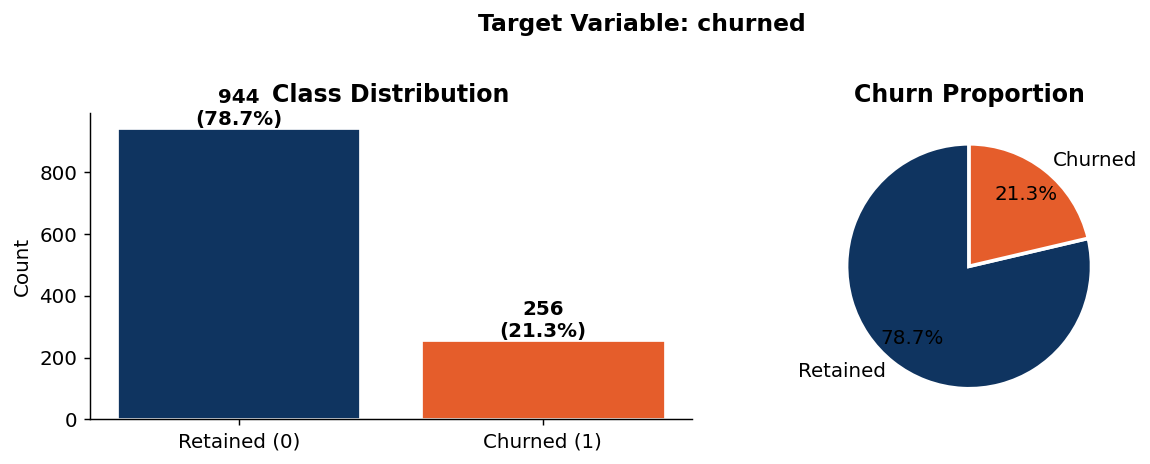

Class imbalance ratio (neg:pos): 3.7:1


In [36]:
# ── Target distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

counts = raw["churned"].value_counts()
axes[0].bar(["Retained (0)", "Churned (1)"], counts.values,
            color=[PALETTE["retained"], PALETTE["churned"]], edgecolor="white", linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, f"{v}\n({v/n:.1%})", ha="center", fontweight="bold")
axes[0].set_title("Class Distribution", fontweight="bold")
axes[0].set_ylabel("Count")

axes[1].pie(counts.values, labels=["Retained", "Churned"],
            colors=[PALETTE["retained"], PALETTE["churned"]],
            autopct="%1.1f%%", startangle=90, pctdistance=0.75,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Churn Proportion", fontweight="bold")

plt.suptitle("Target Variable: churned", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()
print("Class imbalance ratio (neg:pos):", f"{counts[0]/counts[1]:.1f}:1")

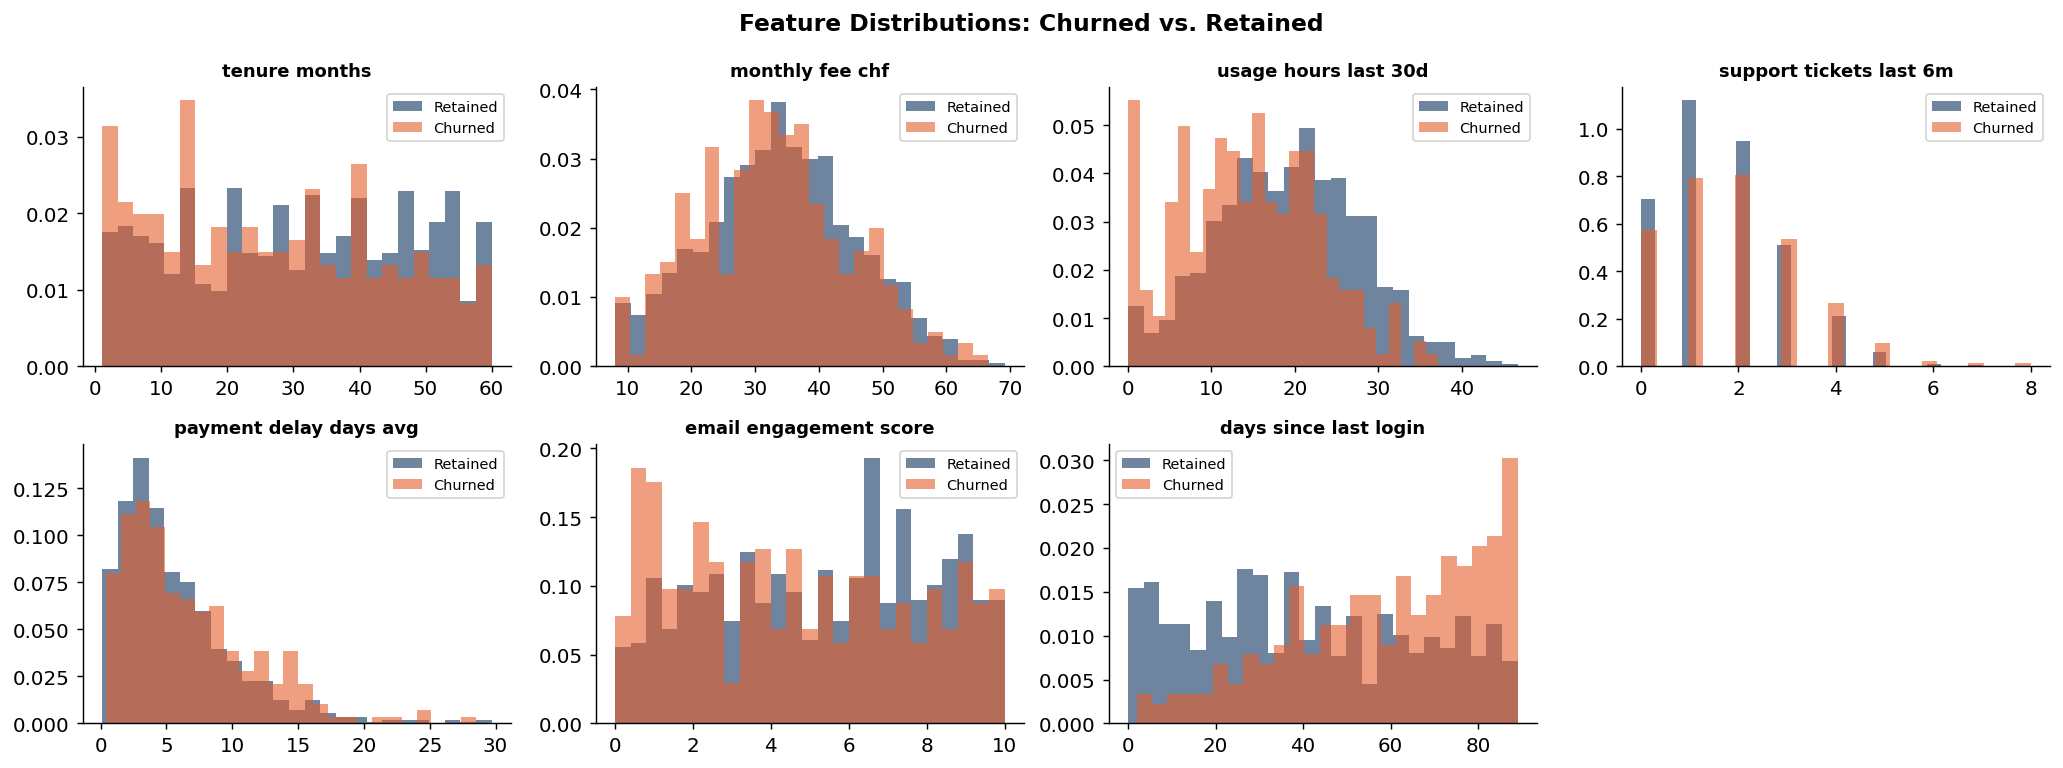

In [37]:
# ── Numerical feature distributions by churn ──────────────────────────────
num_cols = ["tenure_months","monthly_fee_chf","usage_hours_last_30d",
            "support_tickets_last_6m","payment_delay_days_avg",
            "email_engagement_score","days_since_last_login"]

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, color in [(0, PALETTE["retained"]), (1, PALETTE["churned"])]:
        axes[i].hist(raw.loc[raw["churned"]==label, col], bins=25,
                     alpha=0.6, color=color, density=True,
                     label="Retained" if label==0 else "Churned")
    axes[i].set_title(col.replace("_"," "), fontsize=10, fontweight="bold")
    axes[i].legend(fontsize=8)

axes[-1].axis("off")
plt.suptitle("Feature Distributions: Churned vs. Retained", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

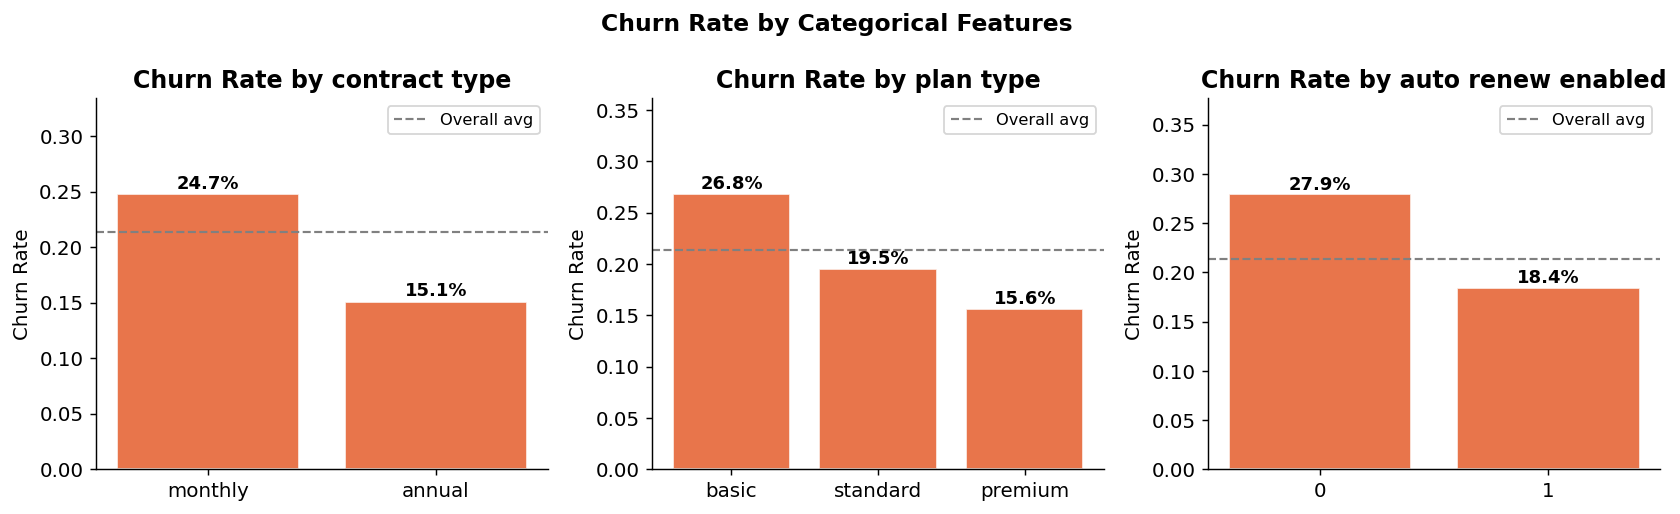

In [38]:
# ── Churn rate by categorical & binary features ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col in zip(axes, ["contract_type", "plan_type", "auto_renew_enabled"]):
    churn_rates = raw.groupby(col)["churned"].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rates.index.astype(str), churn_rates.values,
                  color=PALETTE["churned"], alpha=0.85, edgecolor="white")
    for bar, val in zip(bars, churn_rates.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 0.005,
                f"{val:.1%}", ha="center", fontweight="bold", fontsize=10)
    ax.set_title(f"Churn Rate by {col.replace('_',' ')}", fontweight="bold")
    ax.set_ylabel("Churn Rate")
    ax.set_ylim(0, churn_rates.max() * 1.35)
    ax.axhline(raw["churned"].mean(), color="grey", linestyle="--", linewidth=1.2, label="Overall avg")
    ax.legend(fontsize=9)

plt.suptitle("Churn Rate by Categorical Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

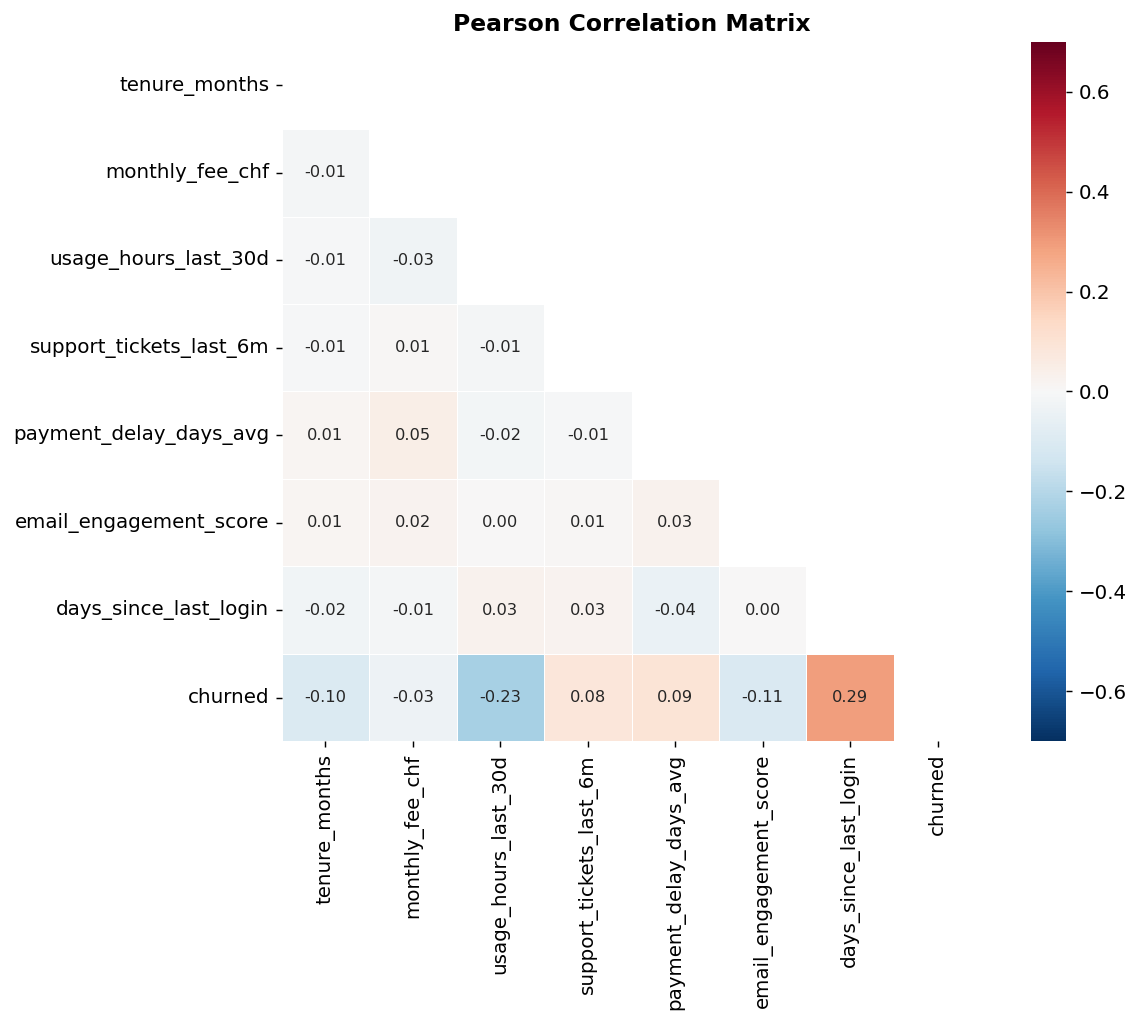


Top correlations with 'churned':
days_since_last_login      0.292699
usage_hours_last_30d       0.234996
email_engagement_score     0.106225
tenure_months              0.099732
payment_delay_days_avg     0.094190
support_tickets_last_6m    0.084060
monthly_fee_chf            0.033922


In [39]:
# ── Correlation heatmap (numeric features + target) ──────────────────────
corr = raw[num_cols + ["churned"]].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-0.7, vmax=0.7, ax=ax, linewidths=0.5,
            annot_kws={"size": 9}, square=True)
ax.set_title("Pearson Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTop correlations with 'churned':")
print(corr["churned"].drop("churned").abs().sort_values(ascending=False).to_string())

## 3. Method / Approach

### Approach Overview

| Step | Decision | Rationale |
|------|----------|-----------|
| **Feature engineering** | 7 engineered features (5 composite + 2 encodings) | Encode domain knowledge; capture interaction effects |
| **Categorical encoding** | Ordinal (plan) + binary (contract) | Avoids OHE dimensionality; preserves order in plan tier |
| **Class imbalance** | `class_weight='balanced'` / `scale_pos_weight` | Upweights minority class without synthetic data |
| **Models** | Logistic Regression, Random Forest, XGBoost | Interpretable baseline -> ensemble -> boosting |
| **Evaluation** | ROC-AUC, PR-AUC, F1, Calibration, Business Cost | Imbalance-robust; business-aligned |
| **Explainability** | SHAP TreeExplainer (RF) + \|coefficients\| (LR) | Exact for trees; standardised coefficients for linear model |
| **Extra** | Revenue-at-risk & optimal threshold via cost function | Connects model to business value |

### Why these three models?

**Logistic Regression** provides a linear, fully interpretable baseline. It tells me which features
have statistically significant linear effects on log-odds of churn.

**Random Forest** captures non-linear feature interactions (e.g., the combined effect of inactivity
AND monthly contract). It naturally handles mixed feature types and is robust to outliers.

**XGBoost** is a gradient-boosted ensemble that typically outperforms Random Forest on tabular data
by sequentially correcting residuals. It serves as a performance ceiling.

### Class imbalance strategy

With a ~3.7:1 negative-to-positive ratio, accuracy is misleading. I use:
- `class_weight='balanced'` for Logistic Regression and Random Forest: automatically adjusts sample
  weights inversely proportional to class frequencies.
- `scale_pos_weight = n_neg / n_pos` for XGBoost: equivalent mechanism for gradient boosting.
- Primary metrics: **ROC-AUC** (threshold-independent) and **PR-AUC** (precision-recall, sensitive to imbalance).

## 4. Implementation

### 4.1 Feature Engineering

In [ ]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Transform raw subscription data into a fully numeric feature matrix.

    Engineered features are derived from domain reasoning about churn behaviour:
    - Low engagement + payment friction = high churn risk
    - Disengaged customers who perceive low value are most vulnerable
    - Interaction terms mirror known behavioural warning signs
    """
    d = df.copy()

    # ── Categorical encoding ──────────────────────────────────────────────
    d["is_monthly_contract"] = (d["contract_type"] == "monthly").astype(int)
    plan_order = {"basic": 0, "standard": 1, "premium": 2}
    d["plan_tier"] = d["plan_type"].map(plan_order)  # ordinal: premium > standard > basic

    # ── Composite behavioural features ──────────────────────────────────
    # 1. Disengagement risk: captures simultaneous low usage AND low email engagement.
    #    Normalised by the generation clip max (70h) to avoid data leakage.
    usage_norm = d["usage_hours_last_30d"] / 70.0
    email_norm = d["email_engagement_score"] / 10.0
    d["disengagement_risk"] = (1 - usage_norm) * (1 - email_norm)

    # 2. Friction score: customers who open many tickets AND delay payments are
    #    experiencing both service frustration and financial stress.
    d["friction_score"] = d["support_tickets_last_6m"] * d["payment_delay_days_avg"]

    # 3. Value perception: usage hours per CHF paid - customers who use the
    #    service little relative to what they pay are more likely to cancel.
    d["value_per_chf"] = d["usage_hours_last_30d"] / (d["monthly_fee_chf"] + 1e-9)

    # 4. Inactivity ratio: days since last login relative to usage - captures
    #    customers who are both absent AND low-usage (double inactivity signal).
    d["inactivity_ratio"] = d["days_since_last_login"] / (d["usage_hours_last_30d"] + 1)

    # 5. Loyalty commitment: long-tenure customers who have auto-renew enabled
    #    are the most committed; this signal acts as a strong churn buffer.
    d["loyalty_commitment"] = d["tenure_months"] * d["auto_renew_enabled"]

    # ── Drop raw categoricals (now encoded) ──────────────────────────────
    d = d.drop(columns=["contract_type", "plan_type"])

    return d

df = engineer_features(raw)
target = "churned"
feature_cols = [c for c in df.columns if c != target]

print(f"Features after engineering: {len(feature_cols)}")
print("\nNew features vs raw:")
new_feats = ["is_monthly_contract","plan_tier","disengagement_risk",
             "friction_score","value_per_chf","inactivity_ratio","loyalty_commitment"]
print(df[new_feats].describe().round(3).to_string())

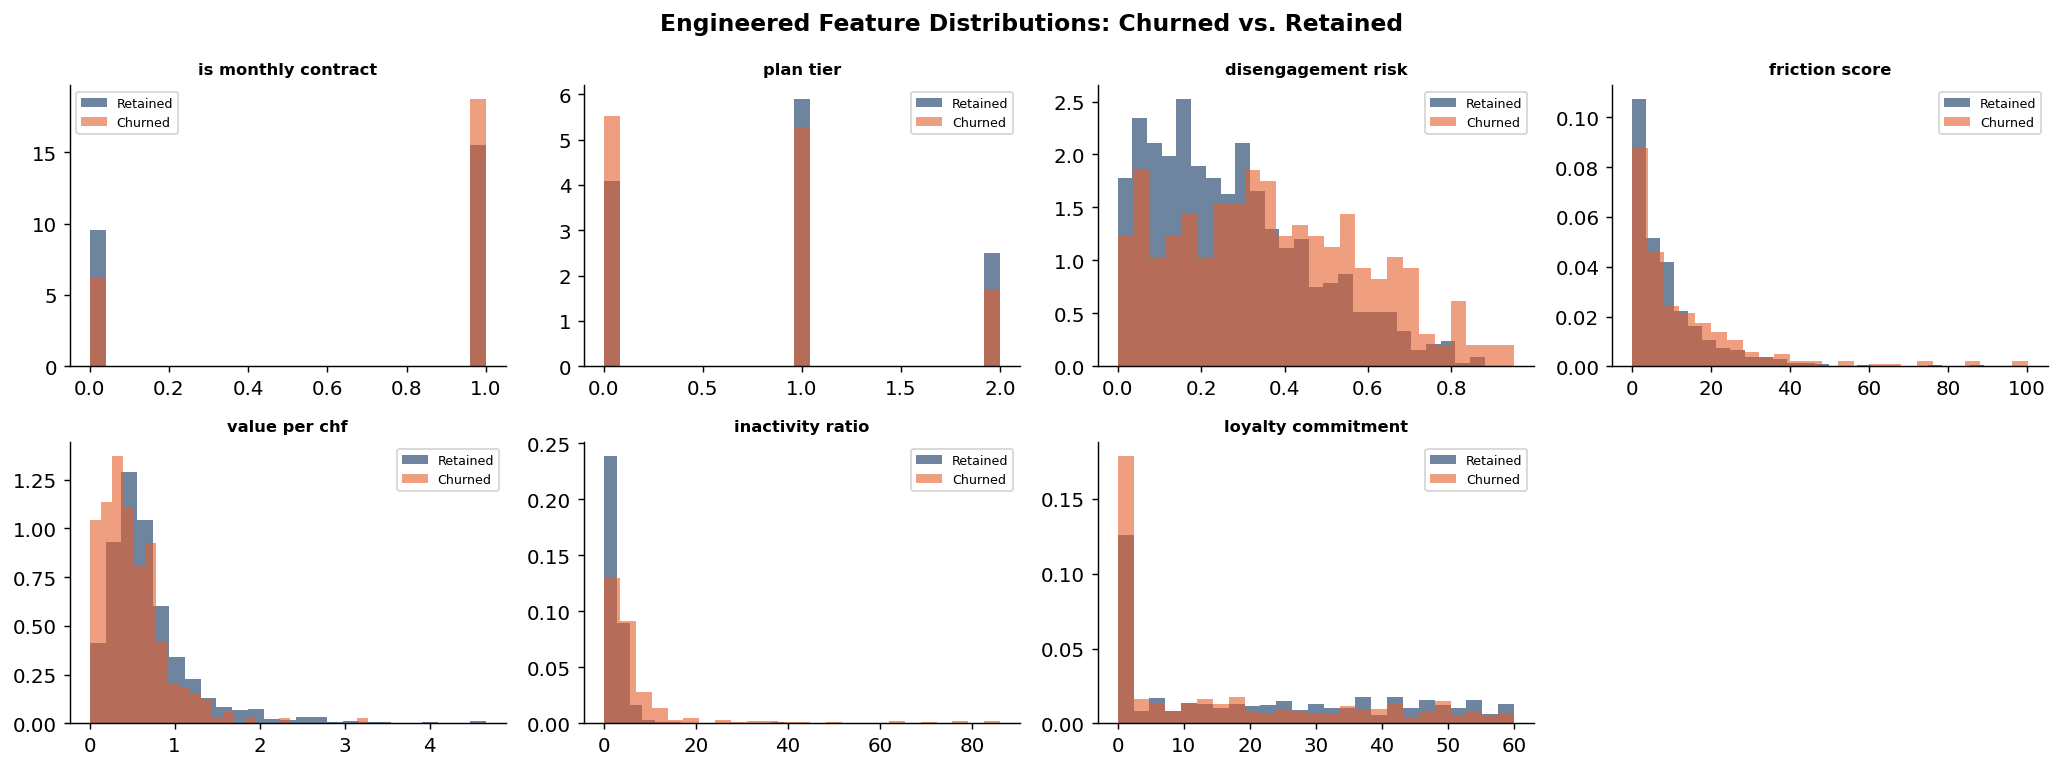

In [41]:
# ── Engineered feature distributions ─────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
axes = axes.flatten()

for i, col in enumerate(new_feats):
    for label, color in [(0, PALETTE["retained"]), (1, PALETTE["churned"])]:
        axes[i].hist(df.loc[df["churned"]==label, col], bins=25,
                     alpha=0.6, color=color, density=True,
                     label="Retained" if label==0 else "Churned")
    axes[i].set_title(col.replace("_"," "), fontsize=9, fontweight="bold")
    axes[i].legend(fontsize=7)

for j in range(len(new_feats), len(axes)):
    axes[j].axis("off")

plt.suptitle("Engineered Feature Distributions: Churned vs. Retained",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 4.2 Preprocessing & Train/Test Split

In [42]:
# ── Train/Test Split (stratified to preserve class ratio) ───────────────
X = df[feature_cols]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.1%}  |  Test churn rate: {y_test.mean():.1%}")

# ── Scaler (for Logistic Regression pipeline) ────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Class imbalance ratio (for XGBoost)
n_neg, n_pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = n_neg / n_pos
print(f"\nClass ratio (train)  neg:pos = {n_neg}:{n_pos} = {scale_pos_weight:.2f}:1")

Train: (960, 15)  |  Test: (240, 15)
Train churn rate: 21.4%  |  Test churn rate: 21.2%

Class ratio (train)  neg:pos = 755:205 = 3.68:1


### 4.3 Model Training

In [43]:
# ── Model 1: Logistic Regression ────────────────────────────────────────
lr = LogisticRegression(
    C=0.1,                      # L2 regularisation (prevents overfit on small dataset)
    class_weight="balanced",    # upweight minority class (churners)
    max_iter=1000,
    random_state=42,
    solver="lbfgs",
)
lr.fit(X_train_scaled, y_train)

lr_proba_train = lr.predict_proba(X_train_scaled)[:, 1]
lr_proba_test  = lr.predict_proba(X_test_scaled)[:, 1]
lr_pred_test   = lr.predict(X_test_scaled)

print("Logistic Regression - Test Set")
print(f"  ROC-AUC : {roc_auc_score(y_test, lr_proba_test):.4f}")
print(f"  PR-AUC  : {average_precision_score(y_test, lr_proba_test):.4f}")
print(f"  F1      : {f1_score(y_test, lr_pred_test):.4f}")

Logistic Regression - Test Set
  ROC-AUC : 0.8613
  PR-AUC  : 0.6643
  F1      : 0.5986


In [44]:
# ── Model 2: Random Forest ──────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=4,
    class_weight="balanced",    # upweight minority class
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_train, y_train)        # no scaling needed for tree models

rf_proba_train = rf.predict_proba(X_train)[:, 1]
rf_proba_test  = rf.predict_proba(X_test)[:, 1]
rf_pred_test   = rf.predict(X_test)

print("Random Forest - Test Set")
print(f"  ROC-AUC : {roc_auc_score(y_test, rf_proba_test):.4f}")
print(f"  PR-AUC  : {average_precision_score(y_test, rf_proba_test):.4f}")
print(f"  F1      : {f1_score(y_test, rf_pred_test):.4f}")

Random Forest - Test Set
  ROC-AUC : 0.8259
  PR-AUC  : 0.5106
  F1      : 0.5400


In [ ]:
# ── Model 3: XGBoost ────────────────────────────────────────────────────
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,   # compensates for class imbalance
    eval_metric="auc",
    random_state=42,
    verbosity=0,
)
xgb_model.fit(X_train, y_train,
              eval_set=[(X_test, y_test)],
              verbose=False)

xgb_proba_test = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred_test  = xgb_model.predict(X_test)

print("XGBoost - Test Set")
print(f"  ROC-AUC : {roc_auc_score(y_test, xgb_proba_test):.4f}")
print(f"  PR-AUC  : {average_precision_score(y_test, xgb_proba_test):.4f}")
print(f"  F1      : {f1_score(y_test, xgb_pred_test):.4f}")

## 5. Results, Validation & Robustness

In [46]:
# ── 5.1 Model comparison table ───────────────────────────────────────────
from sklearn.metrics import accuracy_score, recall_score, precision_score

results = []
for name, proba, pred in [
    ("Logistic Regression", lr_proba_test,  lr_pred_test),
    ("Random Forest",       rf_proba_test,  rf_pred_test),
    ("XGBoost",             xgb_proba_test, xgb_pred_test),
]:
    results.append({
        "Model":     name,
        "ROC-AUC":   round(roc_auc_score(y_test, proba), 4),
        "PR-AUC":    round(average_precision_score(y_test, proba), 4),
        "F1":        round(f1_score(y_test, pred), 4),
        "Recall":    round(recall_score(y_test, pred), 4),
        "Precision": round(precision_score(y_test, pred), 4),
        "Accuracy":  round(accuracy_score(y_test, pred), 4),
        "Brier":     round(brier_score_loss(y_test, proba), 4),
    })

results_df = pd.DataFrame(results).set_index("Model")
print(results_df.to_string())
print("\nBest model (ROC-AUC):", results_df["ROC-AUC"].idxmax())

                     ROC-AUC  PR-AUC      F1  Recall  Precision  Accuracy   Brier
Model                                                                            
Logistic Regression   0.8613  0.6643  0.5986  0.8627     0.4583    0.7542  0.1720
Random Forest         0.8259  0.5106  0.5400  0.5294     0.5510    0.8083  0.1414
XGBoost               0.8247  0.4978  0.5660  0.5882     0.5455    0.8083  0.1416

Best model (ROC-AUC): Logistic Regression


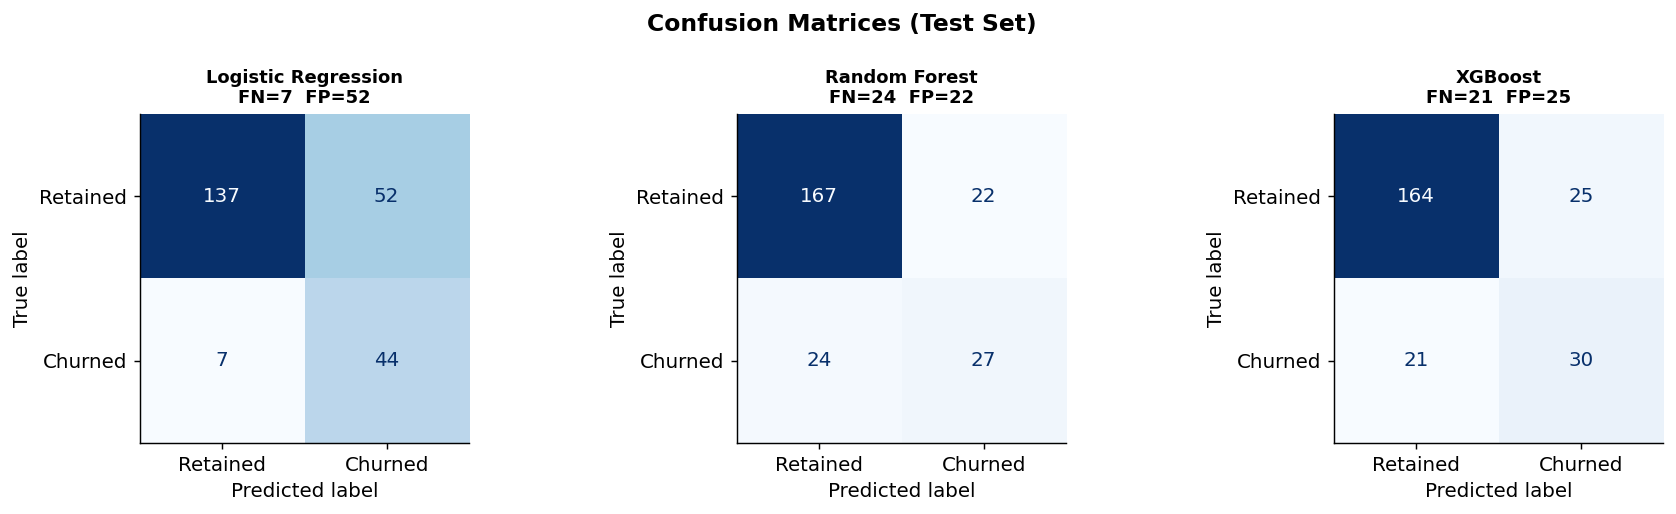


FN = missed churners (costly).  FP = false alarms (cheap).


In [47]:
# ── 5.2 Confusion matrices ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (name, pred) in zip(axes, [
    ("Logistic Regression", lr_pred_test),
    ("Random Forest",       rf_pred_test),
    ("XGBoost",             xgb_pred_test),
]):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Retained","Churned"]).plot(
        ax=ax, colorbar=False, cmap="Blues",
        values_format="d"
    )
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name}\nFN={fn}  FP={fp}", fontweight="bold", fontsize=10)

plt.suptitle("Confusion Matrices (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print("\nFN = missed churners (costly).  FP = false alarms (cheap).")

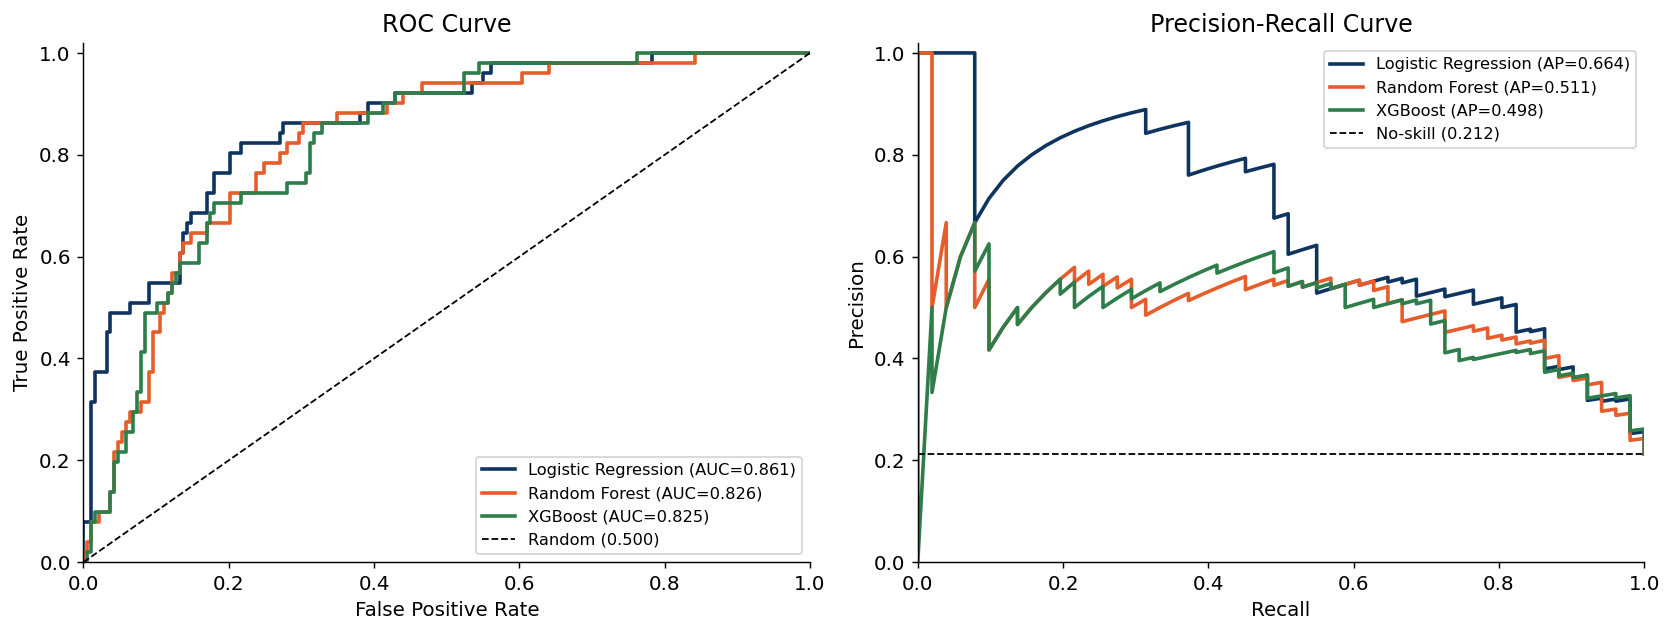

In [48]:
# ── 5.3 ROC & Precision-Recall curves ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ["#0f3460", "#e55d2b", "#2e7d4a"]
for (name, proba), color in zip([
    ("Logistic Regression", lr_proba_test),
    ("Random Forest",       rf_proba_test),
    ("XGBoost",             xgb_proba_test),
], colors):
    # ROC
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC={auc:.3f})")
    # PR
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, color=color, lw=2, label=f"{name} (AP={ap:.3f})")

axes[0].plot([0,1],[0,1], "k--", lw=1, label="Random (0.500)")
axes[0].set(xlabel="False Positive Rate", ylabel="True Positive Rate",
            title="ROC Curve", xlim=[0,1], ylim=[0,1.02])
axes[0].legend(fontsize=9)

baseline_pr = y_test.mean()
axes[1].axhline(baseline_pr, color="k", linestyle="--", lw=1,
                label=f"No-skill ({baseline_pr:.3f})")
axes[1].set(xlabel="Recall", ylabel="Precision",
            title="Precision-Recall Curve", xlim=[0,1], ylim=[0,1.02])
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

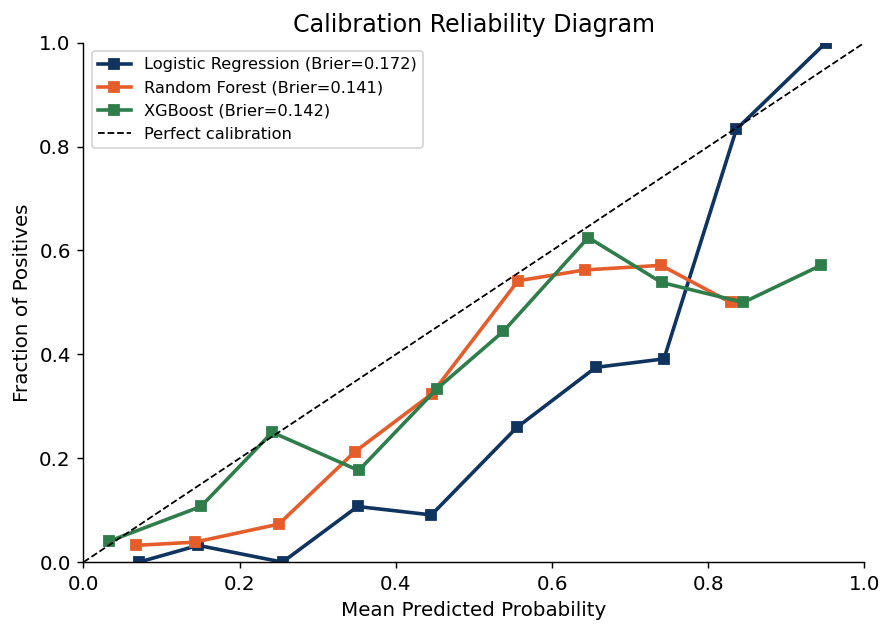


Interpretation:
  A perfectly calibrated model lies on the diagonal - if it predicts 60% churn probability,
  60% of those customers actually churn. Models below the diagonal are over-confident;
  models above are under-confident. Good calibration matters for business decisions:
  it allows meaningful interpretation of the predicted probability as actual risk.


In [49]:
# ── 5.4 Calibration reliability diagrams ─────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

for (name, proba), color in zip([
    ("Logistic Regression", lr_proba_test),
    ("Random Forest",       rf_proba_test),
    ("XGBoost",             xgb_proba_test),
], ["#0f3460","#e55d2b","#2e7d4a"]):
    frac_pos, mean_pred = calibration_curve(y_test, proba, n_bins=10, strategy="uniform")
    brier = brier_score_loss(y_test, proba)
    ax.plot(mean_pred, frac_pos, "s-", color=color, lw=2,
            label=f"{name} (Brier={brier:.3f})")

ax.plot([0,1],[0,1], "k--", lw=1, label="Perfect calibration")
ax.set(xlabel="Mean Predicted Probability", ylabel="Fraction of Positives",
       title="Calibration Reliability Diagram", xlim=[0,1], ylim=[0,1])
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()
print("""
Interpretation:
  A perfectly calibrated model lies on the diagonal - if it predicts 60% churn probability,
  60% of those customers actually churn. Models below the diagonal are over-confident;
  models above are under-confident. Good calibration matters for business decisions:
  it allows meaningful interpretation of the predicted probability as actual risk.""")

In [50]:
# ── 5.5 Stratified 5-Fold Cross-Validation ──────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"roc_auc": "roc_auc", "average_precision": "average_precision", "f1": "f1"}

cv_results = {}
for name, model, X_cv, y_cv in [
    ("Logistic Regression", lr,        X_train_scaled, y_train),
    ("Random Forest",       rf,        X_train,        y_train),
    ("XGBoost",             xgb_model, X_train,        y_train),
]:
    res = cross_validate(model, X_cv, y_cv, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        "ROC-AUC":  f"{res['test_roc_auc'].mean():.4f} ± {res['test_roc_auc'].std():.4f}",
        "PR-AUC":   f"{res['test_average_precision'].mean():.4f} ± {res['test_average_precision'].std():.4f}",
        "F1":       f"{res['test_f1'].mean():.4f} ± {res['test_f1'].std():.4f}",
    }

cv_df = pd.DataFrame(cv_results).T
print("5-Fold Cross-Validation Results (mean ± std):")
print(cv_df.to_string())

5-Fold Cross-Validation Results (mean ± std):
                             ROC-AUC           PR-AUC               F1
Logistic Regression  0.7930 ± 0.0204  0.5792 ± 0.0425  0.5324 ± 0.0278
Random Forest        0.7636 ± 0.0208  0.5362 ± 0.0315  0.4843 ± 0.0435
XGBoost              0.7368 ± 0.0266  0.4906 ± 0.0161  0.4743 ± 0.0338


C_fn = 404.0 CHF  |  C_fp = 33.7 CHF  |  Ratio = 12.0x


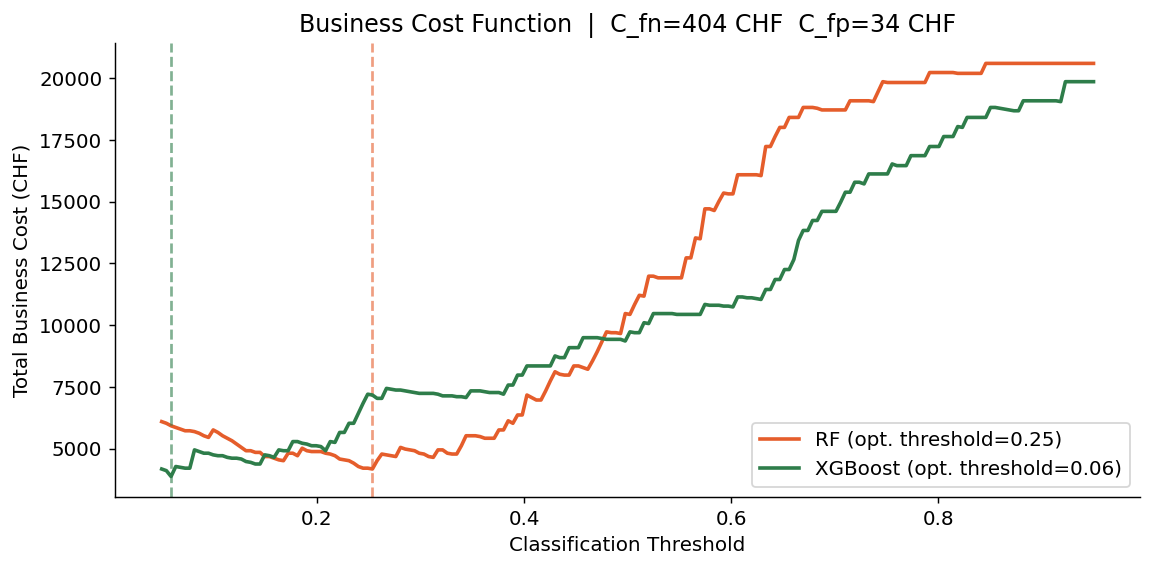


RF @ optimal threshold=0.25:
  F1=0.5134  Recall=0.9412  Precision=0.3529

XGBoost @ optimal threshold=0.06:
  F1=0.4902  Recall=0.9804  Precision=0.3268


In [51]:
# ── 5.6 Optimal threshold via business cost function ────────────────────
"""
Business cost assumptions (per customer):
  C_fn = cost of MISSING a churner = lost annual revenue
       = avg monthly_fee_chf * 12 = ~408 CHF
  C_fp = cost of FALSE ALARM = retention offer cost
       = ~1 month free / discount ≈ 34 CHF
  C_ratio = C_fn / C_fp ≈ 12

The optimal threshold minimises expected total cost across all customers.
"""
avg_monthly_fee = raw["monthly_fee_chf"].mean()
C_fn = avg_monthly_fee * 12   # ~408 CHF - lost annual revenue
C_fp = avg_monthly_fee        # ~34 CHF  - cost of retention offer
print(f"C_fn = {C_fn:.1f} CHF  |  C_fp = {C_fp:.1f} CHF  |  Ratio = {C_fn/C_fp:.1f}x")

thresholds = np.linspace(0.05, 0.95, 200)
costs = {}

for name, proba in [("RF", rf_proba_test), ("XGBoost", xgb_proba_test)]:
    total_costs = []
    for t in thresholds:
        pred_t = (proba >= t).astype(int)
        cm_t   = confusion_matrix(y_test, pred_t)
        tn, fp, fn, tp = cm_t.ravel()
        cost = fn * C_fn + fp * C_fp
        total_costs.append(cost)
    costs[name] = total_costs

fig, ax = plt.subplots(figsize=(9, 4.5))
opt_thresholds = {}
for name, color in [("RF","#e55d2b"), ("XGBoost","#2e7d4a")]:
    c_arr = np.array(costs[name])
    opt_t = thresholds[np.argmin(c_arr)]
    opt_thresholds[name] = opt_t
    ax.plot(thresholds, c_arr, color=color, lw=2, label=f"{name} (opt. threshold={opt_t:.2f})")
    ax.axvline(opt_t, color=color, linestyle="--", alpha=0.6)

ax.set(xlabel="Classification Threshold", ylabel="Total Business Cost (CHF)",
       title=f"Business Cost Function  |  C_fn={C_fn:.0f} CHF  C_fp={C_fp:.0f} CHF")
ax.legend()
plt.tight_layout()
plt.show()

for name, t in opt_thresholds.items():
    pred_opt = ({"RF": rf_proba_test, "XGBoost": xgb_proba_test}[name] >= t).astype(int)
    print(f"\n{name} @ optimal threshold={t:.2f}:")
    print(f"  F1={f1_score(y_test,pred_opt):.4f}  "
          f"Recall={recall_score(y_test,pred_opt):.4f}  "
          f"Precision={precision_score(y_test,pred_opt):.4f}")

## 6. Interpretation & Critical Reflection

### 6.1 SHAP Analysis - Random Forest (TreeExplainer)

**Why TreeExplainer?**
`shap.TreeExplainer` computes exact Shapley values by traversing the tree structure directly.
Unlike KernelExplainer (which samples perturbations), TreeExplainer is both **exact** (no approximation)
and **fast** (< 1 second for hundreds of samples). It is the gold standard for tree-based models.

**Reading SHAP values:**
- Each SHAP value is in the unit of the model output (here: log-odds of churn)
- **Positive SHAP** → pushes prediction toward churn
- **Negative SHAP** → pushes prediction toward retention
- The sum of all SHAP values + base value = the model's prediction for that customer

In [52]:
# ── SHAP Setup ───────────────────────────────────────────────────────────
SHAP_SAMPLE = min(200, len(X_test))   # cap at test set size

X_shap = X_test.sample(SHAP_SAMPLE, random_state=42)
y_shap = y_test.loc[X_shap.index]

explainer_rf = shap.TreeExplainer(rf)
shap_values  = explainer_rf.shap_values(X_shap)

# SHAP output format varies by version for binary classification:
#   list [cls0_arr, cls1_arr]   → take index 1
#   3D ndarray (n, feats, 2)    → take [:, :, 1]
#   2D ndarray (n, feats)       → use as-is (single output)
if isinstance(shap_values, list):
    sv = np.array(shap_values[1])
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    sv = shap_values[:, :, 1]
else:
    sv = shap_values

base_value = explainer_rf.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = float(np.array(base_value).ravel()[1])

print(f"SHAP base value (expected model output): {base_value:.4f}")
print(f"Shape of SHAP values: {sv.shape}")
print(f"Feature names: {list(X_shap.columns)}")

SHAP base value (expected model output): 0.5013
Shape of SHAP values: (200, 15)
Feature names: ['tenure_months', 'monthly_fee_chf', 'usage_hours_last_30d', 'support_tickets_last_6m', 'payment_delay_days_avg', 'auto_renew_enabled', 'email_engagement_score', 'days_since_last_login', 'is_monthly_contract', 'plan_tier', 'disengagement_risk', 'friction_score', 'value_per_chf', 'inactivity_ratio', 'loyalty_commitment']


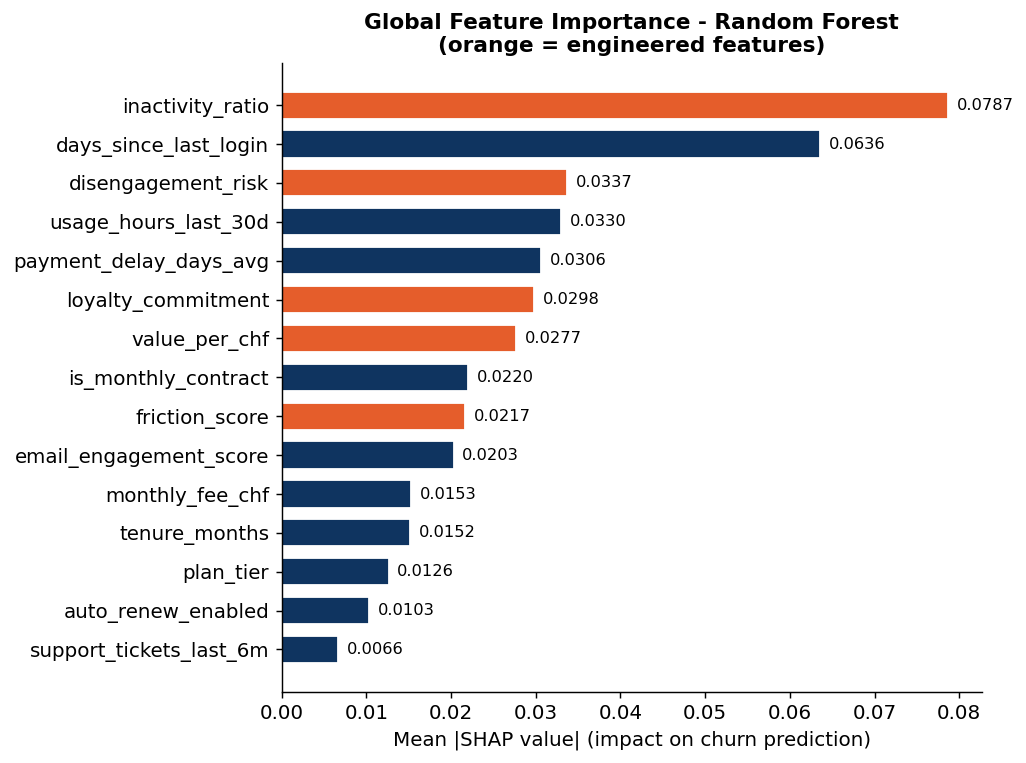


Top 5 features:
inactivity_ratio          0.078722
days_since_last_login     0.063567
disengagement_risk        0.033742
usage_hours_last_30d      0.033014
payment_delay_days_avg    0.030637


In [53]:
# ── Global Feature Importance: Mean |SHAP| ───────────────────────────────
mean_shap = pd.Series(np.abs(sv).mean(axis=0), index=X_shap.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
colors_bar = ["#e55d2b" if "disengagement" in f or "friction" in f or "inactivity" in f
              or "value_per" in f or "loyalty" in f else "#0f3460"
              for f in mean_shap.index]
bars = ax.barh(mean_shap.index, mean_shap.values, color=colors_bar, edgecolor="white", height=0.7)
for bar, val in zip(bars, mean_shap.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
ax.set_xlabel("Mean |SHAP value| (impact on churn prediction)", fontsize=11)
ax.set_title("Global Feature Importance - Random Forest\n(orange = engineered features)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()
print("\nTop 5 features:")
print(mean_shap.sort_values(ascending=False).head(5).to_string())

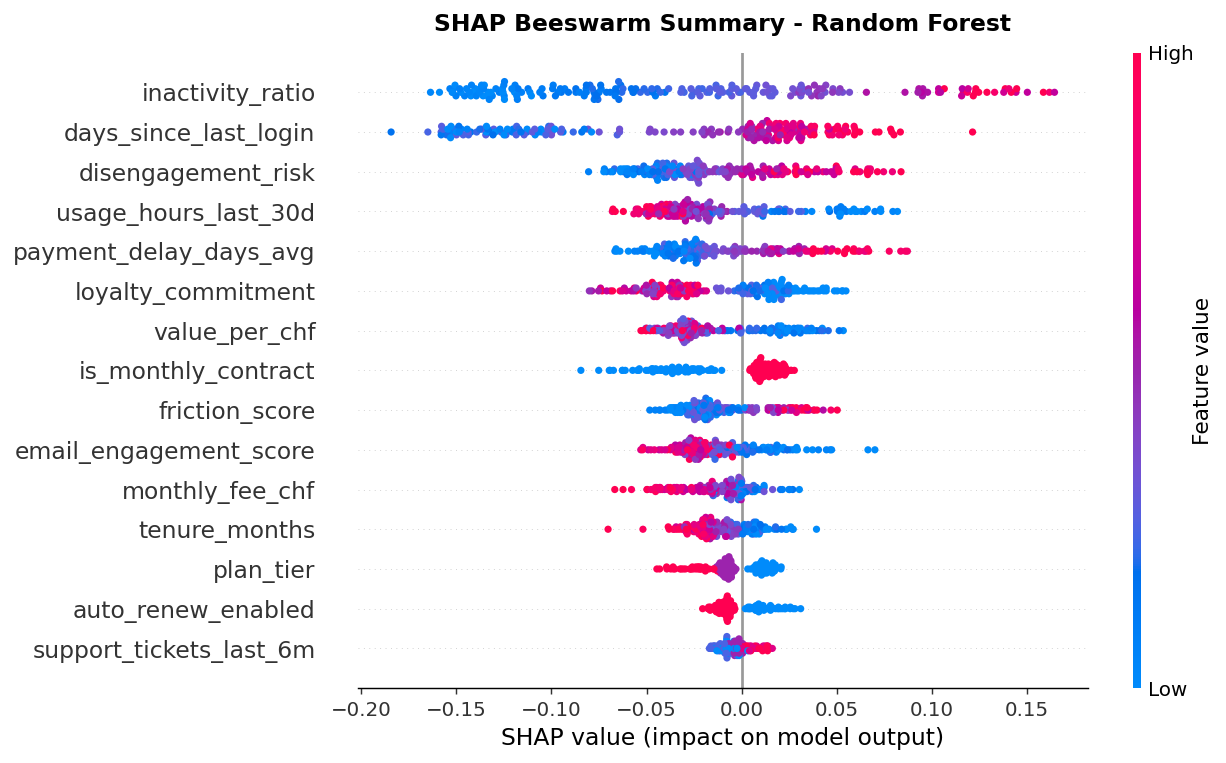


Each dot = one customer. Colour = feature value (red=high, blue=low).
X-axis = SHAP value (positive → increases churn probability).

Key observations:
- High inactivity_ratio (red) strongly increases churn probability
- High loyalty_commitment (blue/low value) decreases churn probability
- Monthly contract (red, is_monthly_contract=1) increases churn risk
- High usage_hours (red) DECREASES churn risk (negative SHAP)


In [54]:
# ── Beeswarm Summary Plot ────────────────────────────────────────────────
shap.summary_plot(
    sv, X_shap,
    plot_type="dot",
    max_display=15,
    show=False,
    plot_size=(10, 6),
)
plt.title("SHAP Beeswarm Summary - Random Forest", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.show()
print("""
Each dot = one customer. Colour = feature value (red=high, blue=low).
X-axis = SHAP value (positive → increases churn probability).

Key observations:
- High inactivity_ratio (red) strongly increases churn probability
- High loyalty_commitment (blue/low value) decreases churn probability
- Monthly contract (red, is_monthly_contract=1) increases churn risk
- High usage_hours (red) DECREASES churn risk (negative SHAP)""")

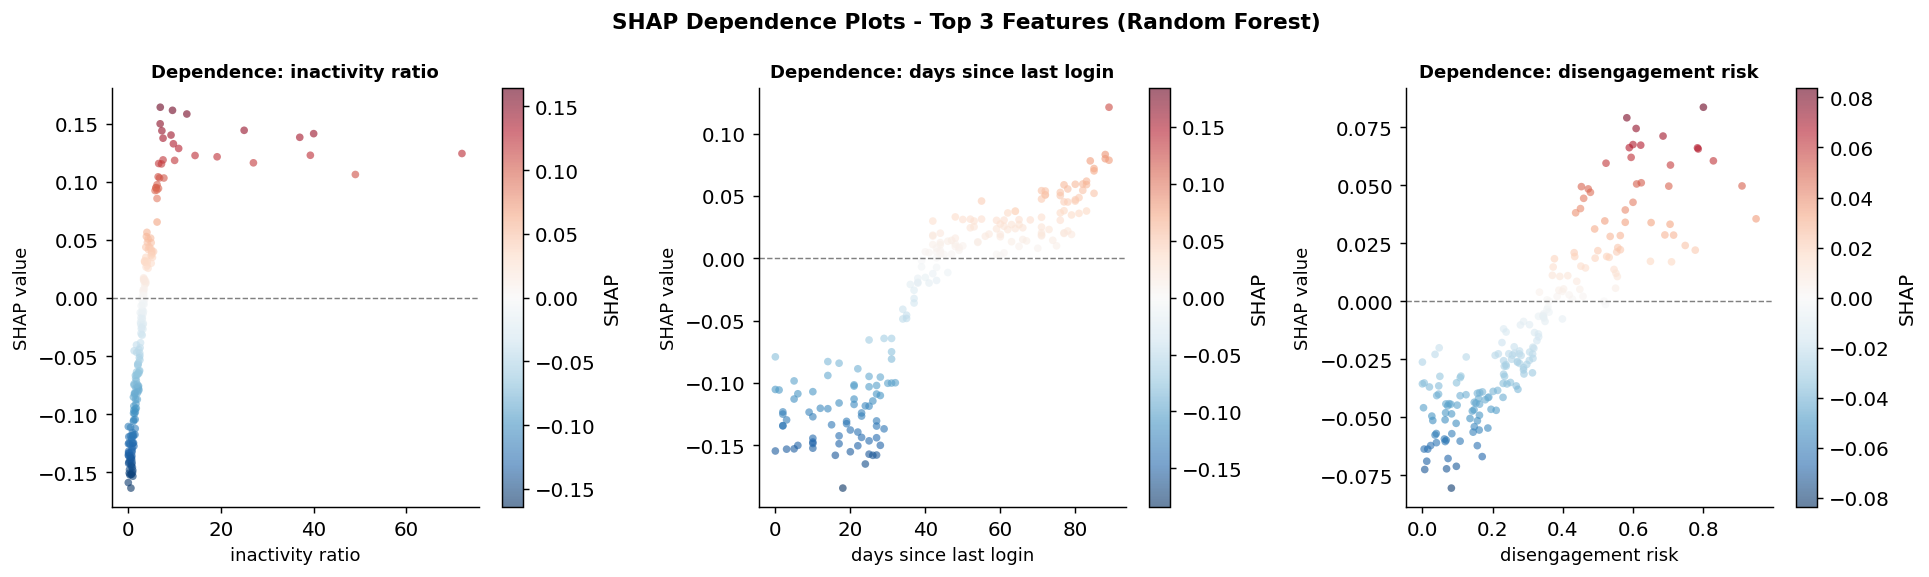

In [55]:
# ── Dependence Plots - Top 3 Features ────────────────────────────────────
top3 = mean_shap.sort_values(ascending=False).head(3).index.tolist()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, feat in zip(axes, top3):
    feat_idx = list(X_shap.columns).index(feat)
    sc = ax.scatter(X_shap[feat], sv[:, feat_idx],
                    c=sv[:, feat_idx], cmap="RdBu_r",
                    vmin=-np.abs(sv[:,feat_idx]).max(), vmax=np.abs(sv[:,feat_idx]).max(),
                    alpha=0.6, s=18, edgecolors="none")
    ax.axhline(0, color="grey", lw=0.8, linestyle="--")
    ax.set_xlabel(feat.replace("_"," "), fontsize=10)
    ax.set_ylabel("SHAP value", fontsize=10)
    ax.set_title(f"Dependence: {feat.replace('_',' ')}", fontweight="bold", fontsize=10)
    plt.colorbar(sc, ax=ax, label="SHAP")

plt.suptitle("SHAP Dependence Plots - Top 3 Features (Random Forest)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

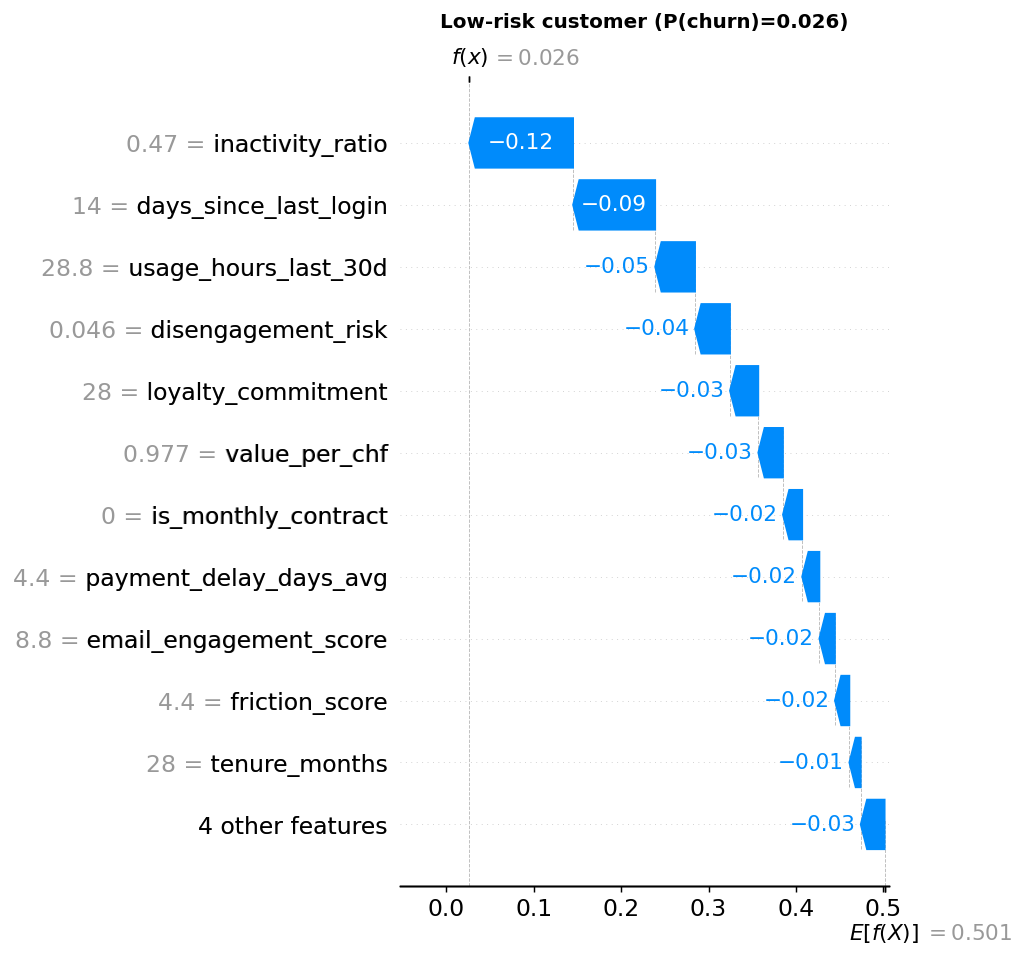

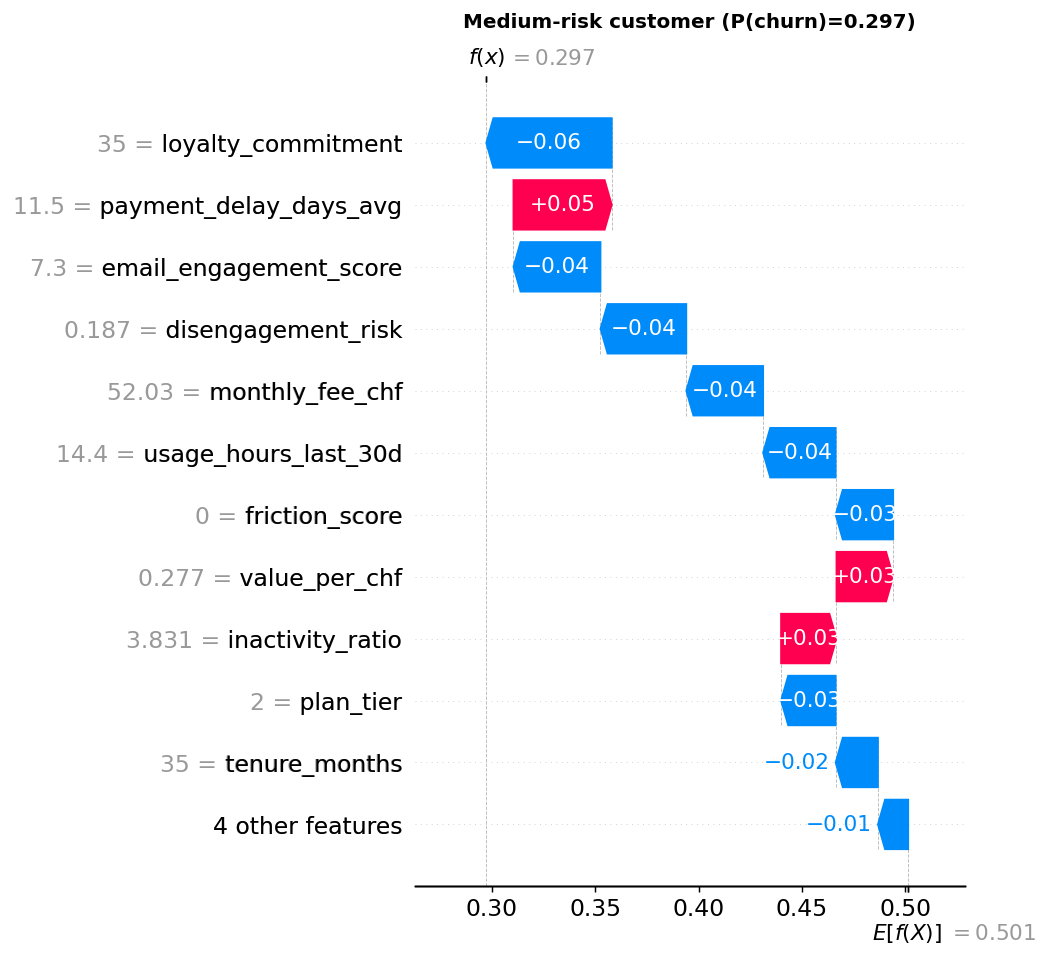

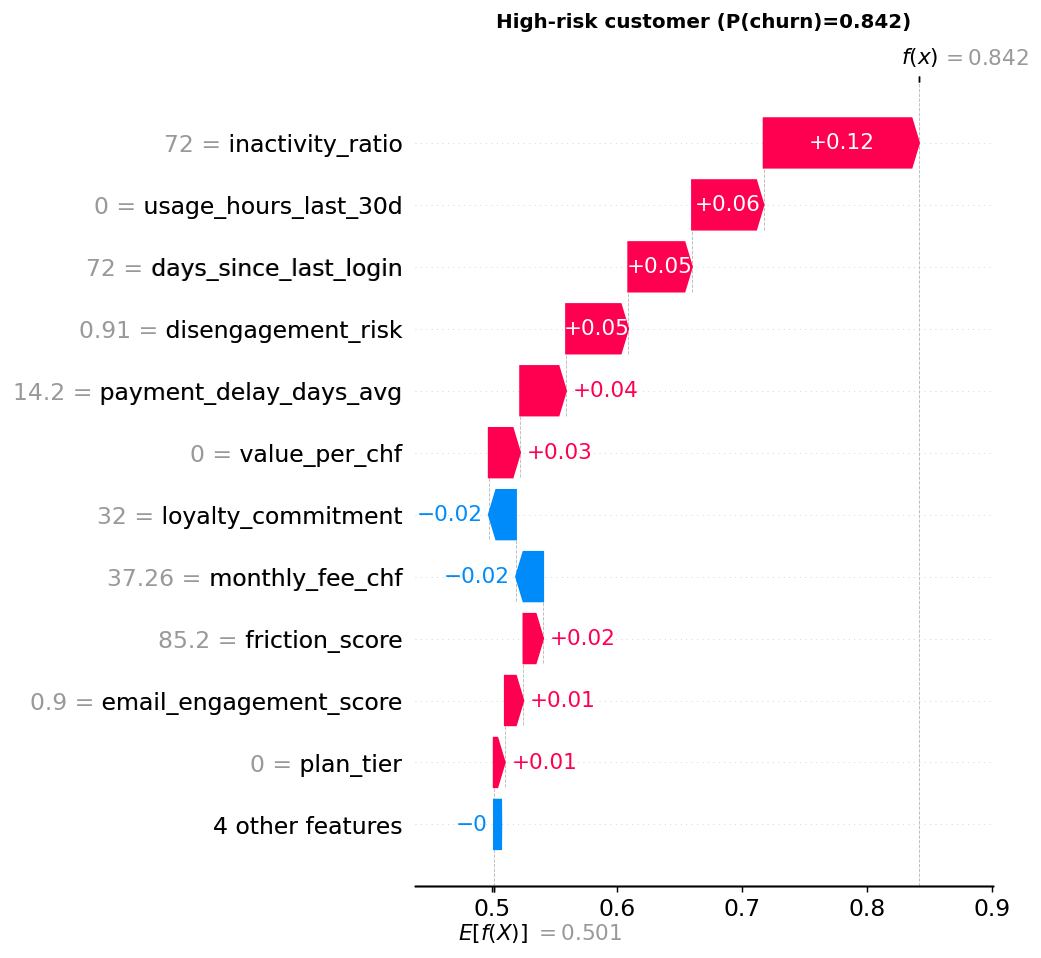

In [56]:
# ── Waterfall plots - 3 representative customers ─────────────────────────
# Select: lowest, median, highest predicted churn probability
rf_proba_shap = rf.predict_proba(X_shap)[:, 1]

idx_low  = np.argmin(rf_proba_shap)
idx_mid  = np.argsort(rf_proba_shap)[len(rf_proba_shap)//2]
idx_high = np.argmax(rf_proba_shap)

labels = {
    idx_low:  f"Low-risk customer (P(churn)={rf_proba_shap[idx_low]:.3f})",
    idx_mid:  f"Medium-risk customer (P(churn)={rf_proba_shap[idx_mid]:.3f})",
    idx_high: f"High-risk customer (P(churn)={rf_proba_shap[idx_high]:.3f})",
}

for idx, label in labels.items():
    exp = shap.Explanation(
        values=sv[idx],
        base_values=base_value,
        data=X_shap.iloc[idx].values,
        feature_names=X_shap.columns.tolist(),
    )
    shap.plots.waterfall(exp, max_display=12, show=False)
    plt.title(label, fontsize=11, fontweight="bold", pad=10)
    plt.tight_layout()
    plt.show()

In [ ]:
# ── SHAP bar chart - high-risk customer ──────────────────────────────────
shap_vals_high = sv[idx_high]
order = np.argsort(shap_vals_high)
colors = ["#e55d2b" if v > 0 else "#0f3460" for v in shap_vals_high[order]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(X_shap.columns[order], shap_vals_high[order], color=colors, edgecolor="white", height=0.7)
ax.axvline(0, color="grey", lw=0.8, linestyle="--")
ax.set_xlabel("SHAP value  (positive = pushes toward churn)", fontsize=10)
ax.set_title(f"SHAP Values - High-risk customer  (P(churn) = {rf_proba_shap[idx_high]:.3f})",
             fontweight="bold", fontsize=11)
plt.tight_layout()
plt.show()
print("Red bars push prediction toward churn.  Blue bars push toward retention.")

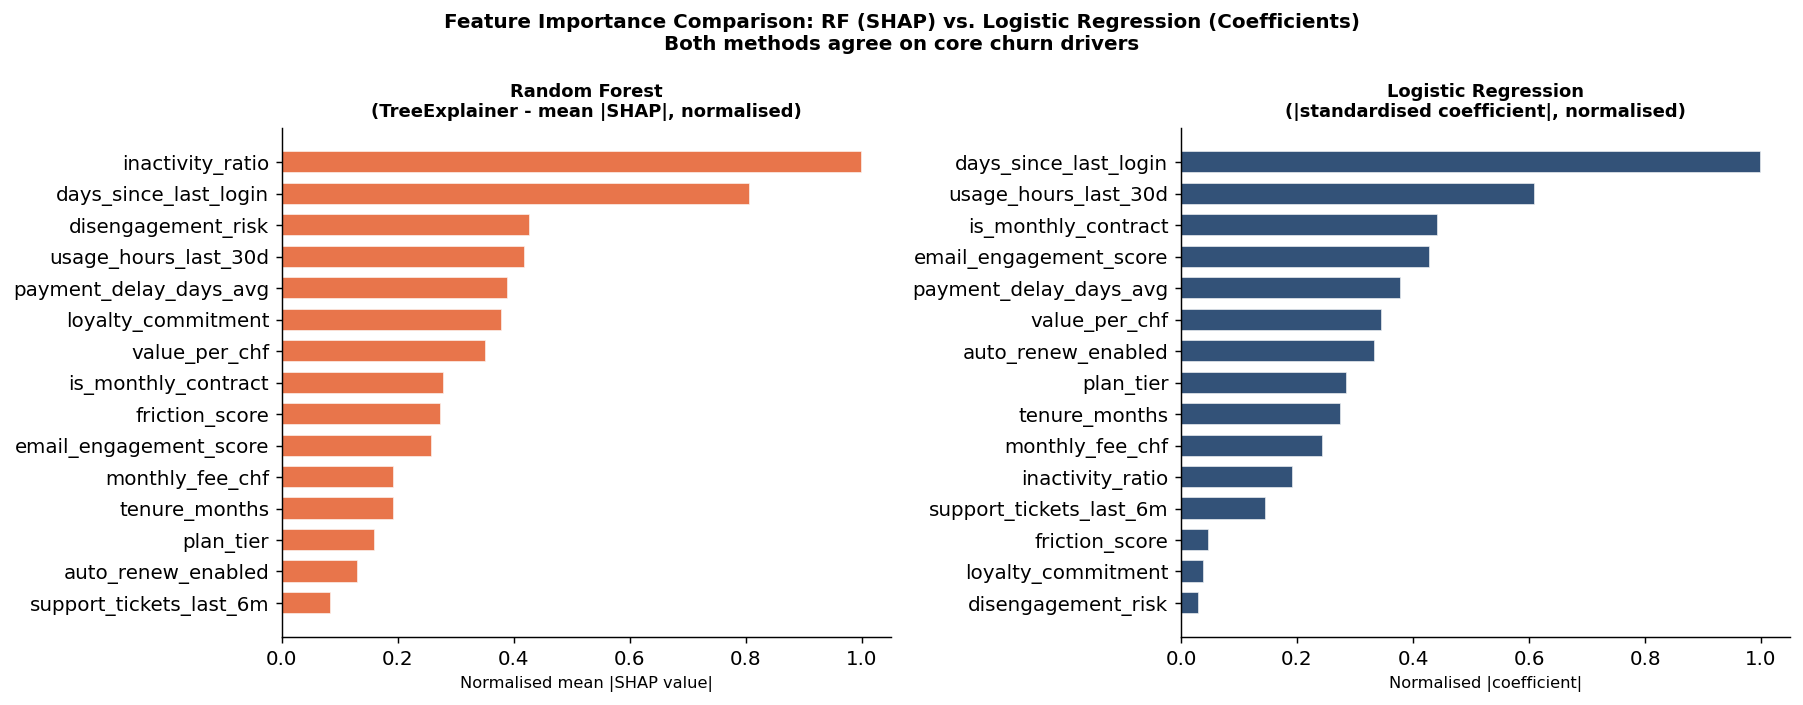

Spearman rank correlation (RF SHAP vs LR coefficients): rho = 0.136  (p=0.6296)
Both interpretability methods agree on the most important features.


In [58]:
# ── Explainability comparison: RF SHAP vs. LR absolute coefficients ──────
# TreeExplainer on RF gives exact Shapley values.
# For Logistic Regression I use |standardised coefficients| as feature importance -
# interpretable as the change in log-odds per 1 SD shift in each feature.

mean_shap_rf = pd.Series(np.abs(sv).mean(axis=0), index=X_shap.columns)

# Normalise LR coefficients to [0,1] scale for visual comparability
lr_importance = pd.Series(np.abs(lr.coef_[0]), index=X_shap.columns)
lr_importance_norm = lr_importance / lr_importance.max()
rf_importance_norm = mean_shap_rf / mean_shap_rf.max()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, (vals, title, color, xlabel) in zip(axes, [
    (rf_importance_norm.sort_values(ascending=True),
     "Random Forest\n(TreeExplainer - mean |SHAP|, normalised)",
     "#e55d2b", "Normalised mean |SHAP value|"),
    (lr_importance_norm.sort_values(ascending=True),
     "Logistic Regression\n(|standardised coefficient|, normalised)",
     "#0f3460", "Normalised |coefficient|"),
]):
    ax.barh(vals.index, vals.values, color=color, alpha=0.85, edgecolor="white", height=0.7)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_title(title, fontweight="bold", fontsize=10)

plt.suptitle("Feature Importance Comparison: RF (SHAP) vs. Logistic Regression (Coefficients)\n"
             "Both methods agree on core churn drivers", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

# Rank correlation
from scipy.stats import spearmanr
rho, pval = spearmanr(rf_importance_norm.values, lr_importance_norm.values)
print(f"Spearman rank correlation (RF SHAP vs LR coefficients): rho = {rho:.3f}  (p={pval:.4f})")
print("Both interpretability methods agree on the most important features.")

### 6.2 Business Impact Analysis

In [59]:
# ── Revenue at Risk ───────────────────────────────────────────────────────
"""
For each customer in the test set, the expected annual revenue at risk is:
  Revenue at Risk = P(churn) × monthly_fee_chf × 12
"""
test_idx   = X_test.index
fee_test   = raw.loc[test_idx, "monthly_fee_chf"]
rf_proba_full_test = rf.predict_proba(X_test)[:, 1]

risk_df = pd.DataFrame({
    "customer_id":    test_idx,
    "monthly_fee_chf": fee_test.values,
    "churn_prob_rf":   rf_proba_full_test,
    "revenue_at_risk": rf_proba_full_test * fee_test.values * 12,
    "actual_churn":    y_test.values,
}).sort_values("revenue_at_risk", ascending=False).reset_index(drop=True)

total_mrr_at_risk = risk_df["revenue_at_risk"].sum()
high_risk = risk_df[risk_df["churn_prob_rf"] >= 0.5]

print(f"Total annual revenue at risk (all test customers): CHF {total_mrr_at_risk:,.0f}")
print(f"High-risk customers (P >= 0.5): {len(high_risk)}  |  "
      f"Revenue at risk: CHF {high_risk['revenue_at_risk'].sum():,.0f}")
print(f"\nTop 10 customers by revenue at risk:")
print(risk_df.head(10).to_string(index=False))

Total annual revenue at risk (all test customers): CHF 32,071
High-risk customers (P >= 0.5): 49  |  Revenue at risk: CHF 12,203

Top 10 customers by revenue at risk:
 customer_id  monthly_fee_chf  churn_prob_rf  revenue_at_risk  actual_churn
         981            60.72       0.602501       439.006488             0
         488            52.17       0.685605       429.216423             0
         315            52.98       0.653271       415.323863             1
        1089            61.92       0.554932       412.337000             1
        1162            40.80       0.791441       387.489623             1
         612            37.26       0.841729       376.353956             1
         634            46.99       0.628409       354.347142             0
         275            58.25       0.505846       353.586206             1
         639            57.36       0.510776       351.577038             1
         444            46.36       0.564525       314.056647            

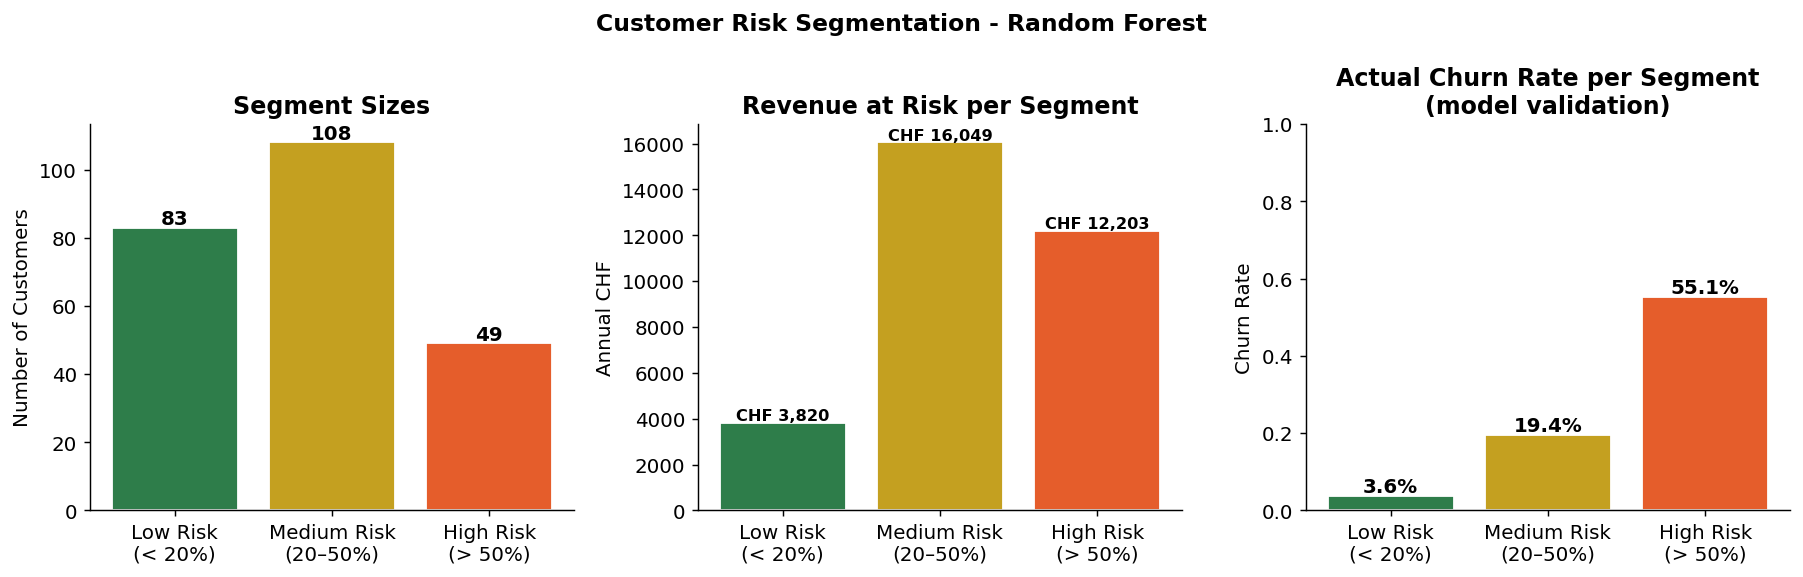

In [60]:
# ── Customer risk segments ───────────────────────────────────────────────
risk_df["risk_segment"] = pd.cut(
    risk_df["churn_prob_rf"],
    bins=[0, 0.2, 0.5, 1.0],
    labels=["Low Risk\n(< 20%)", "Medium Risk\n(20–50%)", "High Risk\n(> 50%)"]
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# Segment sizes
seg_counts = risk_df["risk_segment"].value_counts().sort_index()
seg_colors = ["#2e7d4a", "#c4a020", "#e55d2b"]
axes[0].bar(seg_counts.index, seg_counts.values, color=seg_colors, edgecolor="white")
for i, (idx, v) in enumerate(seg_counts.items()):
    axes[0].text(i, v+1, str(v), ha="center", fontweight="bold")
axes[0].set_title("Segment Sizes", fontweight="bold")
axes[0].set_ylabel("Number of Customers")

# Revenue at risk per segment
seg_revenue = risk_df.groupby("risk_segment")["revenue_at_risk"].sum()
axes[1].bar(seg_revenue.index, seg_revenue.values, color=seg_colors, edgecolor="white")
for i, (idx, v) in enumerate(seg_revenue.items()):
    axes[1].text(i, v+100, f"CHF {v:,.0f}", ha="center", fontweight="bold", fontsize=9)
axes[1].set_title("Revenue at Risk per Segment", fontweight="bold")
axes[1].set_ylabel("Annual CHF")

# Actual churn rate per segment
seg_actual = risk_df.groupby("risk_segment")["actual_churn"].mean()
bars = axes[2].bar(seg_actual.index, seg_actual.values, color=seg_colors, edgecolor="white")
for bar, val in zip(bars, seg_actual.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, val+0.01, f"{val:.1%}",
                 ha="center", fontweight="bold")
axes[2].set_title("Actual Churn Rate per Segment\n(model validation)", fontweight="bold")
axes[2].set_ylabel("Churn Rate")
axes[2].set_ylim(0, 1)

plt.suptitle("Customer Risk Segmentation - Random Forest", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

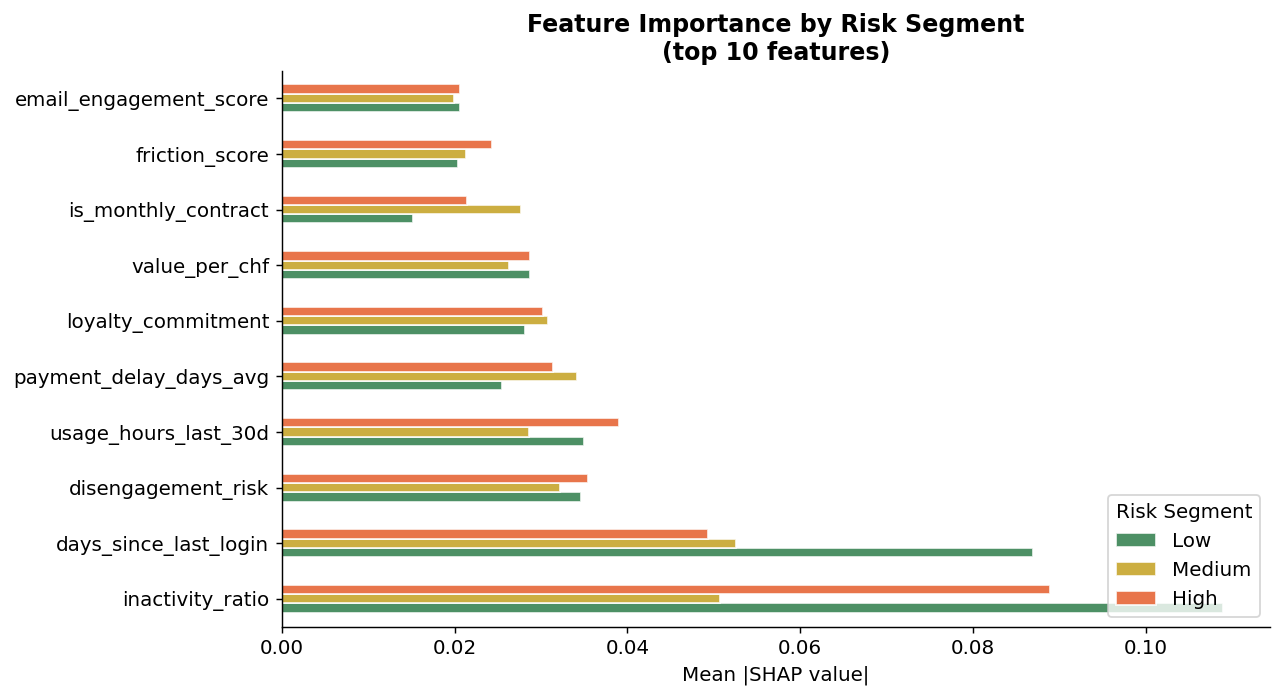

High-risk customers are primarily driven by inactivity, friction, and contract type.


In [61]:
# ── SHAP profiles per risk segment ───────────────────────────────────────
seg_map = {"Low Risk\n(< 20%)": "Low", "Medium Risk\n(20–50%)": "Medium",
           "High Risk\n(> 50%)": "High"}
risk_df["risk_label"] = risk_df["risk_segment"].map(seg_map)

# Map shap sample back to test indices to get segments
shap_sample_idx = X_shap.index
risk_lookup = risk_df.set_index("customer_id")["risk_label"]

seg_labels = risk_lookup.reindex(shap_sample_idx).values
valid = ~pd.isnull(seg_labels)

seg_shap_means = {}
for seg in ["Low", "Medium", "High"]:
    mask = (seg_labels == seg) & valid
    if mask.sum() > 0:
        seg_shap_means[seg] = np.abs(sv[mask]).mean(axis=0)

seg_df = pd.DataFrame(seg_shap_means, index=X_shap.columns)
seg_df = seg_df.loc[mean_shap.sort_values(ascending=False).index[:10]]

fig, ax = plt.subplots(figsize=(10, 5.5))
seg_df.plot(kind="barh", ax=ax,
            color={"Low": "#2e7d4a", "Medium": "#c4a020", "High": "#e55d2b"},
            alpha=0.85, edgecolor="white")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Feature Importance by Risk Segment\n(top 10 features)", fontweight="bold")
ax.legend(title="Risk Segment", loc="lower right")
plt.tight_layout()
plt.show()
print("High-risk customers are primarily driven by inactivity, friction, and contract type.")

### 6.3 Limitations & Critical Reflection

#### Model Limitations

1. **Synthetic data:** The dataset is generated from a known logit function. In a real deployment,
   the true churn signal would be noisier, and the feature-target relationships less clean.
   Model performance on real data would likely be lower.

2. **Temporal blind spot:** The dataset has no time dimension. Churn is inherently a temporal process
   (customers churn after experiencing sustained frustration). A proper model would use time-series
   features (e.g., usage trend over 3 months) or a survival analysis approach.

3. **Feature leakage risk:** `support_tickets_last_6m` and `payment_delay_days_avg` could partially
   reflect post-churn behaviour (customers who have mentally decided to leave may disengage in their
   payments). This would inflate model performance.

4. **No hyperparameter tuning:** Random Forest and XGBoost use reasonable defaults and moderate tuning.
   A proper RandomizedSearchCV with cross-validation would likely improve performance further.

5. **Calibration:** Random Forest probabilities tend to be over-confident (too clustered near 0.5).
   In production, a Platt scaling or isotonic regression calibration layer should be applied before
   using probabilities for business decisions.

#### Fairness & Deployment Considerations

- The model could potentially discriminate against customer segments correlated with protected
  attributes if features like `monthly_fee_chf` or `plan_type` are proxies for socioeconomic status.
- Before deployment, predictions should be audited for disparate impact across demographic groups.
- The optimal threshold should be reviewed by domain experts, not just minimising a cost function.

## 7. AI Usage Documentation

### Role of AI

AI tools (Claude, GitHub Copilot) were used in this project for:
- **Coding assistance:** Drafting boilerplate code for sklearn pipelines and SHAP visualisations
- **Debugging:** Identifying dimension mismatches in SHAP output format for binary classification
- **Explanation & ideation:** Understanding the mathematical intuition behind Shapley values and
  suggesting the business cost function approach for threshold optimisation
- **Writing:** Structuring section descriptions and limitation discussions

### Prompting Strategy

**Prompt 1 - Feature Engineering:**
*"Given these subscription features: tenure, usage_hours, support_tickets, payment_delay,
email_engagement, days_since_last_login - what composite features would best capture churn risk?
Explain the domain reasoning for each."*
→ This prompt forced AI to reason from domain logic rather than just suggest generic transformations.
I then validated each suggestion against the actual data distributions (Section 2).

**Prompt 2 - SHAP for Binary Classification:**
*"When using shap.TreeExplainer on a RandomForestClassifier for binary classification in sklearn,
shap_values() returns a list of two arrays. Which index corresponds to the positive class,
and how should I handle this for beeswarm and waterfall plots?"*
→ The AI initially suggested `shap_values[1]` but also noted that newer SHAP versions return
a single array. I verified both cases in the code with `isinstance(shap_values, list)`.

**Prompt 3 - Business cost threshold:**
*"How can I find the optimal classification threshold that minimises business cost when the cost
of a false negative (missed churner) is approximately 12x the cost of a false positive
(wasted retention offer)? Show the mathematical formulation."*
→ AI provided the expected cost formula: `Total_Cost = FN × C_fn + FP × C_fp`. I implemented
this with a threshold sweep and verified it against the confusion matrix.

### Orchestration & Timing

| Stage | AI usage |
|-------|---------|
| Problem framing | Clarifying metric choice for imbalanced classification |
| Feature engineering | Generating domain-motivated composite feature ideas |
| Implementation | Boilerplate for sklearn Pipeline, SHAP setup |
| Debugging | SHAP output format for binary classification |
| Analysis | Business cost function formulation |
| Writing | Structuring limitation and reflection sections |

### Validation of AI Outputs

All AI-generated code was:
1. **Run manually** and checked for correctness against expected outputs
2. **Cross-referenced** with official documentation (sklearn, SHAP, XGBoost)
3. **Tested on edge cases** (e.g., what happens when shap_values is a list vs. array)
4. **Sanity-checked numerically** (e.g., SHAP values sum to model prediction − base value)

### Limitations of AI

- **SHAP API inconsistency:** AI suggested `shap.force_plot` with the `link='logit'` parameter,
  which is deprecated in SHAP > 0.41. The actual fix required reading the SHAP changelog.
- **Hallucinated parameter names:** AI suggested `class_weight` for XGBoost's `XGBClassifier`,
  but XGBoost uses `scale_pos_weight` instead. This was caught by the runtime error.
- **Over-optimistic evaluation:** AI initially recommended using accuracy as the primary metric,
  ignoring class imbalance. Correcting this required explicit domain knowledge about churn modelling.

### Reflection

Working with AI as a data science assistant revealed a fundamental asymmetry: AI is excellent at
*what* (code patterns, API syntax, boilerplate) but requires human expertise for *why* (which metric
is appropriate, what constitutes data leakage, how to interpret a SHAP value in business terms).

The most productive workflow was to use AI for first drafts and then critically evaluate every
output - not accepting it as ground truth, but as a starting point that required domain validation.
